In [ ]:
!pip install kagglehub matplotlib scikit-learn seaborn
!python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached kagglesdk-0.1.18-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached numpy-2.4.4-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aditya126/basic-maths-symbols-dataset")

print("Path to dataset files:", path)

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/aidenye2/.cache/kagglehub/datasets/aditya126/basic-maths-symbols-dataset/versions/2


In [ ]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("cuda device count:", torch.cuda.device_count())

torch version: 2.11.0+cu128
cuda available: True
torch cuda version: 12.8
cuda device count: 1


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using device: cuda


In [ ]:
# Inspect folder layout
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = '  ' * (level + 1)
        for f in files[:3]:
            print(f"{subindent}{f}")
        if len(files) > 3:
            print(f"{subindent}... ({len(files)} files)")

2/
  symbol_dataset/
    close_bracket/
    divide/
    equals/
    minus/
    multiply/
    open_bracket/
    plus/
    times/


In [ ]:
# Auto-detect the root image directory (handles nested dataset layouts)
def find_image_root(base_path):
    """Walk until we find a folder whose children are class subdirectories."""
    for root, dirs, files in os.walk(base_path):
        subdirs = [d for d in dirs if not d.startswith('.')]
        if subdirs and not files:  # looks like a class-folder layout
            # Verify children contain images
            sample_child = os.path.join(root, subdirs[0])
            sample_files = os.listdir(sample_child)
            if any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in sample_files):
                return root
    return base_path

IMAGE_ROOT = find_image_root(path)
print(f"Image root: {IMAGE_ROOT}")

# List the 8 classes
classes = sorted([d for d in os.listdir(IMAGE_ROOT)
                  if os.path.isdir(os.path.join(IMAGE_ROOT, d))])
print(f"Classes ({len(classes)}): {classes}")

# Count samples per class
print("\nSamples per class:")
for c in classes:
    n = len(os.listdir(os.path.join(IMAGE_ROOT, c)))
    print(f"  {c:20s}: {n}")

Image root: /home/aidenye2/.cache/kagglehub/datasets/aditya126/basic-maths-symbols-dataset/versions/2/symbol_dataset
Classes (8): ['close_bracket', 'divide', 'equals', 'minus', 'multiply', 'open_bracket', 'plus', 'times']

Samples per class:
  close_bracket       : 7500
  divide              : 7500
  equals              : 7500
  minus               : 7500
  multiply            : 7500
  open_bracket        : 7500
  plus                : 7500
  times               : 7500


In [ ]:
IMG_H      = 32
IMG_W      = 16
BATCH_SIZE = 64
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15

class BlackInkOnWhite:
    """Make inputs match FPGA normalized chars: black ink on white background."""
    def __init__(self, threshold=192):
        self.threshold = threshold

    def __call__(self, img):
        img = img.convert("L")
        arr = np.array(img)
        if arr.mean() < 127:
            img = ImageOps.invert(img)
        img = ImageOps.autocontrast(img)
        arr = np.array(img)
        bw = np.where(arr < self.threshold, 0, 255).astype(np.uint8)
        return Image.fromarray(bw, mode="L")

class SaltPepperNoise:
    """Salt/pepper speckle augmentation before ToTensor()."""
    def __init__(self, p=0.85, salt_prob=0.006, pepper_prob=0.006):
        self.p = p
        self.salt_prob = salt_prob
        self.pepper_prob = pepper_prob

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img = img.convert("L")

        arr = np.array(img).copy()
        h, w = arr.shape
        salt = np.random.rand(h, w) < self.salt_prob
        pepper = np.random.rand(h, w) < self.pepper_prob
        arr[salt] = 255
        arr[pepper] = 0

        return Image.fromarray(arr.astype(np.uint8), mode="L")

# ── Shared transforms ────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_H, IMG_W)),
    BlackInkOnWhite(threshold=192),
    SaltPepperNoise(p=0.85, salt_prob=0.003, pepper_prob=0.003),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])
eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_H, IMG_W)),
    BlackInkOnWhite(threshold=192),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# ── Math-symbol dataset (ImageFolder) ────────────────────────────────────────
symbol_train_ds = datasets.ImageFolder(IMAGE_ROOT, transform=train_transforms)
symbol_eval_ds  = datasets.ImageFolder(IMAGE_ROOT, transform=eval_transforms)
symbol_classes  = symbol_train_ds.classes          # e.g. ['div', 'eq', ...]
n_sym           = len(symbol_classes)

# ── MNIST digits (10 classes: 0–9) ───────────────────────────────────────────
# MNIST ships with torchvision; no extra download needed beyond PyPI.
# We need to re-label MNIST targets so they don't clash with symbol indices.
# Convention:  label 0..n_sym-1  → math symbols
#              label n_sym..n_sym+9 → digits 0–9

class ShiftedMNIST(torch.utils.data.Dataset):
    """Wrap a torchvision MNIST split and shift all labels by `offset`."""
    def __init__(self, root, train: bool, transform, offset: int):
        self.mnist  = datasets.MNIST(root=root, train=train,
                                     transform=transform, download=True)
        self.offset = offset

    def __len__(self):  return len(self.mnist)

    def __getitem__(self, idx):
        img, label = self.mnist[idx]
        return img, label + self.offset

MNIST_ROOT   = "/tmp/mnist"
mnist_offset = n_sym   # digits start right after symbol classes

mnist_train_full = ShiftedMNIST(MNIST_ROOT, train=True,
                                transform=train_transforms, offset=mnist_offset)
mnist_test_full  = ShiftedMNIST(MNIST_ROOT, train=False,
                                transform=eval_transforms,  offset=mnist_offset)

# ── Build class_names list: symbols first, then '0'..'9' ─────────────────────
digit_names = [str(d) for d in range(10)]
class_names = symbol_classes + digit_names
NUM_CLASSES = len(class_names)   # n_sym + 10
print(f"Total classes: {NUM_CLASSES}  = {n_sym} symbols + 10 digits")
print(f"class_names: {class_names}")

# ── Split math-symbol data into train / val / test ───────────────────────────
n_total  = len(symbol_train_ds)
n_test_s = int(n_total * TEST_SPLIT)
n_val_s  = int(n_total * VAL_SPLIT)
n_train_s = n_total - n_val_s - n_test_s

generator = torch.Generator().manual_seed(42)
indices   = torch.randperm(n_total, generator=generator).tolist()

sym_train_ds = torch.utils.data.Subset(symbol_train_ds, indices[:n_train_s])
sym_val_ds   = torch.utils.data.Subset(symbol_eval_ds,  indices[n_train_s:n_train_s + n_val_s])
sym_test_ds  = torch.utils.data.Subset(symbol_eval_ds,  indices[n_train_s + n_val_s:])

# ── Split MNIST eval set into val / test ──────────────────────────────────────
# MNIST already has a canonical train/test split (60k / 10k).
# We use the 10k test set and split it 50/50 for val & test.
n_mnist_test = len(mnist_test_full)
n_mnist_val  = n_mnist_test // 2
n_mnist_te   = n_mnist_test - n_mnist_val

gen2 = torch.Generator().manual_seed(42)
mnist_val_ds, mnist_test_ds = torch.utils.data.random_split(
    mnist_test_full, [n_mnist_val, n_mnist_te], generator=gen2)

# ── Concatenate symbol + MNIST splits ────────────────────────────────────────
train_ds = torch.utils.data.ConcatDataset([sym_train_ds, mnist_train_full])
val_ds   = torch.utils.data.ConcatDataset([sym_val_ds,   mnist_val_ds])
test_ds  = torch.utils.data.ConcatDataset([sym_test_ds,  mnist_test_ds])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\nTrain: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 50.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.44MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 12.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.3MB/s]

Total classes: 18  = 8 symbols + 10 digits
class_names: ['close_bracket', 'divide', 'equals', 'minus', 'multiply', 'open_bracket', 'plus', 'times', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Train: 102,000  |  Val: 14,000  |  Test: 14,000


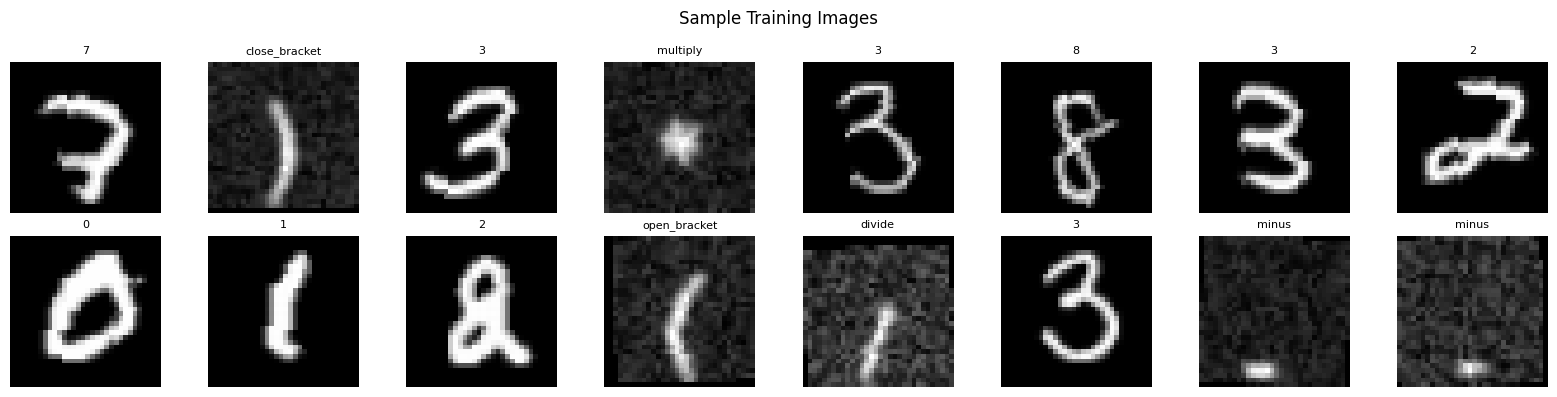

In [ ]:
# Visualise a batch of training samples
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)   # un-normalise
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
class TinyMathCNN(nn.Module):
    """Tiny CNN for math-symbol + digit classification.

    Input : (B, 1, 32, 16)  — grayscale 32 high × 16 wide
    Output: (B, NUM_CLASSES) — logits for symbols + digits

    Architecture change vs the 8-class version:
      • Added a 3rd conv block (8→16 channels) for extra capacity.
      • Input shape changed to 32 high × 16 wide to match FPGA normalize output.
      • Output head is now num_classes (18 by default: 8 symbols + 10 digits).
    Hidden-neuron count is 80, intentionally above the old 70 target.
    """

    def __init__(self, num_classes: int = 18):
        super().__init__()

        # ── Feature extractor ───────────────────────────────────────────────
        self.features = nn.Sequential(
            # Block 1  [B, 1, 32, 16] -> [B, 8, 16, 8]
            nn.Conv2d(1, 8, kernel_size=3, padding=1, bias=False),
            #nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2  [B, 8, 16, 8] -> [B, 16, 8, 4]
            nn.Conv2d(8, 16, kernel_size=3, padding=1, bias=False),
            #nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3  [B, 16, 8, 4] -> [B, 24, 4, 2]
            nn.Conv2d(16, 24, kernel_size=3, padding=1, bias=False),
            #nn.BatchNorm2d(24),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # ── Classifier ──────────────────────────────────────────────────────
        # After 3 pools on 32x16: spatial = 4x2, channels = 24 -> 192 flat
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(24 * 4 * 2, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))

    @staticmethod
    def neuron_count() -> int:
        """Conv output channels + hidden FC units (= 8 + 16 + 24 + 32)."""
        return 8 + 16 + 24 + 32  # = 80  (output head excluded; changes with num_classes)


model = TinyMathCNN(num_classes=NUM_CLASSES).to(DEVICE)

total_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_neurons = TinyMathCNN.neuron_count()

print(model)
print(f"\nNeurons : {total_neurons} hidden")
print(f"Params  : {total_params:,}")
print(f"Classes : {NUM_CLASSES}")


TinyMathCNN(
  (features): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=16, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=16, out_features=18, bias=True)
  )
)

Neurons : 60 hidden  (budget: ≤70)
Params  : 5,894
Classes : 18


In [ ]:
# ── Hyper-parameters ────────────────────────────────────────────────────────
EPOCHS    = 10
LR        = 1e-3
PATIENCE  = 7        # early-stopping patience

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── Training loop ───────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc   = 0.0
patience_count = 0
best_state     = None


def run_epoch(loader, training=True):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            if training:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(lbls)
            correct    += (out.argmax(1) == lbls).sum().item()
            total      += len(lbls)
    return total_loss / total, correct / total


print(f"{'Epoch':>5} {'Train Loss':>10} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>10} {'LR':>8}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    current_lr = scheduler.get_last_lr()[0]
    print(f"{epoch:5d} {tr_loss:10.4f} {tr_acc:9.2%} {vl_loss:10.4f} {vl_acc:9.2%} {current_lr:8.6f}")

    # Early stopping + checkpoint
    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

# Restore best weights
model.load_state_dict(best_state)
print(f"\nBest validation accuracy: {best_val_acc:.2%}")

Epoch Train Loss  Train Acc   Val Loss    Val Acc       LR
------------------------------------------------------------
    1     1.4333    48.90%     0.3986    93.75% 0.000976
    2     0.8540    70.60%     0.1888    97.40% 0.000905
    3     0.6665    77.18%     0.1379    98.36% 0.000794
    4     0.5904    79.76%     0.1016    98.27% 0.000655
    5     0.5330    81.59%     0.0772    98.86% 0.000500
    6     0.4804    83.33%     0.0720    99.07% 0.000345
    7     0.4603    84.12%     0.0601    99.06% 0.000206
    8     0.4449    84.60%     0.0574    99.05% 0.000095
    9     0.4379    84.92%     0.0550    99.16% 0.000024
   10     0.4308    85.31%     0.0524    99.17% 0.000000

Best validation accuracy: 99.17%


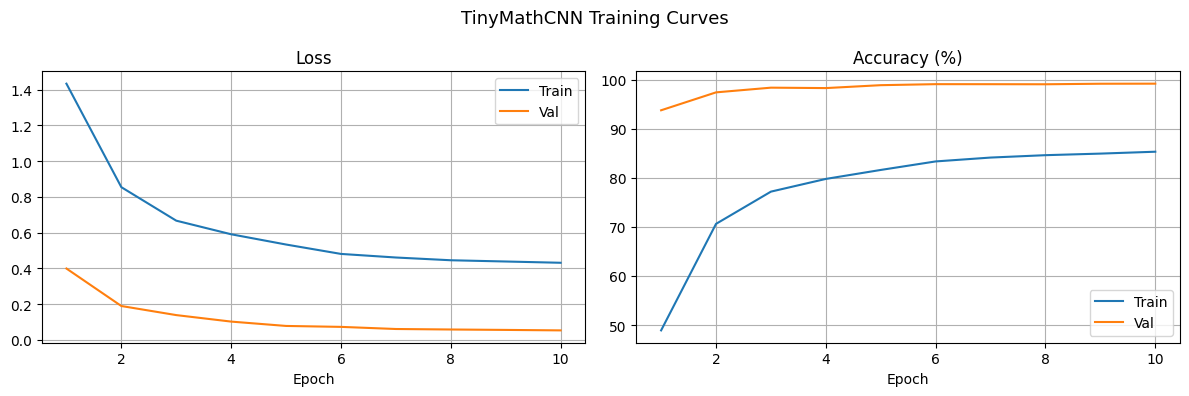

In [ ]:
epochs_ran = len(history["train_loss"])
xs = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(xs, history["train_loss"], label="Train")
ax1.plot(xs, history["val_loss"],   label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True)

ax2.plot(xs, [a * 100 for a in history["train_acc"]], label="Train")
ax2.plot(xs, [a * 100 for a in history["val_acc"]],   label="Val")
ax2.set_title("Accuracy (%)"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True)

plt.suptitle("TinyMathCNN Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(lbls.tolist())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test Accuracy : {test_acc:.2%}")
print(f"\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy : 99.09%

Classification Report:

               precision    recall  f1-score   support

close_bracket       1.00      1.00      1.00      1115
       divide       1.00      1.00      1.00      1147
       equals       1.00      1.00      1.00      1112
        minus       1.00      1.00      1.00      1148
     multiply       1.00      1.00      1.00      1169
 open_bracket       1.00      1.00      1.00      1096
         plus       1.00      1.00      1.00      1085
        times       1.00      1.00      1.00      1128
            0       0.97      0.99      0.98       451
            1       0.99      0.99      0.99       553
            2       0.97      0.97      0.97       495
            3       0.97      0.98      0.98       530
            4       0.98      0.98      0.98       501
            5       0.98      0.98      0.98       449
            6       0.98      0.97      0.97       460
            7       0.97      0.98      0.98       531
            8   

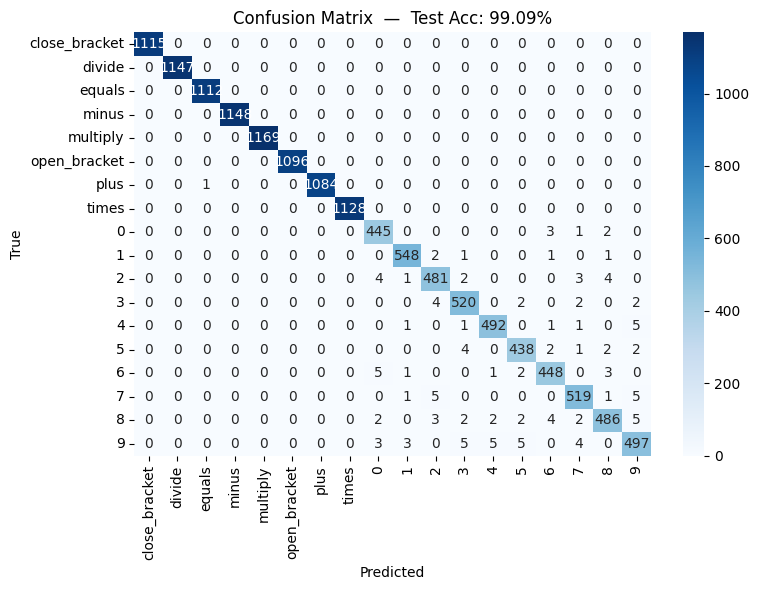

In [ ]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix  —  Test Acc: {test_acc:.2%}')
plt.tight_layout()
plt.show()

In [ ]:

model.eval()  # VERY IMPORTANT

# ─────────────────────────────────────────────
# Q8.8 quantization
# ─────────────────────────────────────────────
FRAC_BITS = 8
SCALE = 2 ** FRAC_BITS

def quantize_q8_8(tensor):
    q = torch.round(tensor * SCALE)
    q = torch.clamp(q, -32768, 32767)  # int16 range
    return q.to(torch.int16)

# ─────────────────────────────────────────────
# Save helper
# ─────────────────────────────────────────────
outdir = Path("vivado_q8_8")
outdir.mkdir(exist_ok=True)

def save_flat(name, tensor):
    arr = tensor.cpu().numpy().reshape(-1).astype(np.int16)
    np.savetxt(outdir / f"{name}.txt", arr, fmt="%d")
    with open(outdir / f"{name}.mem", "w") as f:
        for value in arr:
            f.write(f"{np.uint16(value):04x}\n")

def hw_char_code(name):
    key = str(name).strip().lower()
    aliases = {
        "+": 10, "plus": 10, "add": 10,
        "-": 11, "minus": 11, "sub": 11, "subtract": 11,
        "*": 12, "x": 12, "times": 12, "mul": 12, "multiply": 12,
        "=": 13, "eq": 13, "equal": 13, "equals": 13,
        "(": 14, "lparen": 14, "left_paren": 14, "left_parenthesis": 14,
        "open_paren": 14, "open_parenthesis": 14, "open_bracket": 14,
        ")": 15, "rparen": 15, "right_paren": 15, "right_parenthesis": 15,
        "close_paren": 15, "close_parenthesis": 15, "close_bracket": 15,
    }
    if key.isdigit() and len(key) == 1:
        return int(key)
    return aliases.get(key, 15)  # unsupported classes map to ')' / parser skip

def save_class_codes(names):
    codes = [hw_char_code(name) for name in names]
    np.savetxt(outdir / "class_code.txt", np.array(codes, dtype=np.int16), fmt="%d")
    with open(outdir / "class_code.mem", "w") as f:
        for code in codes:
            f.write(f"{code & 0xF:x}\n")

# ─────────────────────────────────────────────
# Extract + quantize layers
# ─────────────────────────────────────────────

# Conv layers
conv1_w = quantize_q8_8(model.features[0].weight)
conv2_w = quantize_q8_8(model.features[3].weight)
conv3_w = quantize_q8_8(model.features[6].weight)

# NOTE: bias=False → no biases for convs

# FC layers
fc1_w = quantize_q8_8(model.classifier[1].weight)
fc1_b = quantize_q8_8(model.classifier[1].bias)

fc2_w = quantize_q8_8(model.classifier[4].weight)
fc2_b = quantize_q8_8(model.classifier[4].bias)

# ─────────────────────────────────────────────
# Save everything
# ─────────────────────────────────────────────

save_flat("conv1_weight", conv1_w)
save_flat("conv2_weight", conv2_w)
save_flat("conv3_weight", conv3_w)

save_flat("fc1_weight", fc1_w)
save_flat("fc1_bias",   fc1_b)

save_flat("fc2_weight", fc2_w)
save_flat("fc2_bias",   fc2_b)
save_class_codes(class_names)

print("Saved Q8.8 weights to:", outdir.resolve())

Saved Q8.8 weights to: /home/aidenye2/385/vivado_q8_8


In [ ]:
print("=" * 40)
print("  TinyMathCNN — Final Summary")
print("=" * 40)
print(f"  Neurons       : {TinyMathCNN.neuron_count()} hidden")
print(f"  Parameters    : {total_params:,}")
print(f"  Classes       : {len(class_names)}")
print(f"  Input size    : 1 × {IMG_H} × {IMG_W}")
print(f"  Best val acc  : {best_val_acc:.2%}")
print(f"  Test acc      : {test_acc:.2%}")
print("=" * 40)

# Save model weights
torch.save({
    "model_state_dict" : model.state_dict(),
    "class_names"      : class_names,
    "img_h"            : IMG_H,
    "img_w"            : IMG_W,
    "test_accuracy"    : test_acc,
}, "tiny_math_cnn.pt")
print("\nModel saved to tiny_math_cnn.pt")

Prediction : plus  (99.7% confidence)
Prediction : plus  (100.0% confidence)
Prediction : plus  (99.9% confidence)
Prediction : plus  (98.7% confidence)


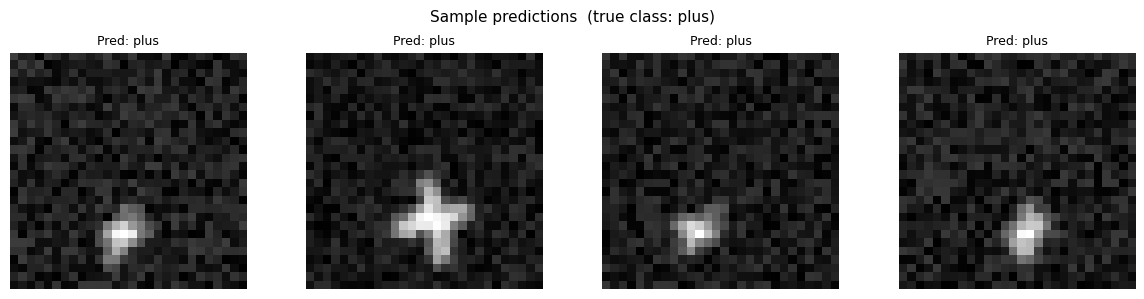

In [ ]:
from PIL import Image

def predict(image_path: str) -> str:
    """Predict the math symbol in a single image file."""
    img = Image.open(image_path).convert("L")
    tensor = eval_transforms(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()
    pred_idx   = probs.argmax().item()
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx].item()
    print(f"Prediction : {pred_class}  ({confidence:.1%} confidence)")
    return pred_class


# Demo: run on a few test images
test_dir = os.path.join(IMAGE_ROOT, class_names[6])
sample_images = [
    os.path.join(test_dir, f)
    for f in os.listdir(test_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
][:4]

fig, axes = plt.subplots(1, len(sample_images), figsize=(12, 3))
for ax, img_path in zip(axes, sample_images):
    pred = predict(img_path)
    img  = Image.open(img_path).convert("L")
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {pred}", fontsize=9)
    ax.axis('off')
plt.suptitle(f'Sample predictions  (true class: {class_names[6]})', fontsize=11)
plt.tight_layout()
plt.show()